In [1]:
# QRISK3 Calculator - Session 1
# Let's collect some patient information

print("=== QRISK3 Cardiovascular Risk Calculator ===")
print()

# Patient inputs
age = int(input("Age: "))
systolic_bp = float(input("Systolic BP (mmHg): "))
total_cholesterol = float(input("Total cholesterol (mmol/L): "))
hdl_cholesterol = float(input("HDL cholesterol (mmol/L): "))
smoker = input("Smoker? (never/ex/light/moderate/heavy): ").lower()
diabetic = input("Type 2 diabetes? (yes/no): ").lower()
sex = input("Sex (male/female): ").lower()

# Calculate cholesterol ratio
chol_ratio = total_cholesterol / hdl_cholesterol

print()
print(f"--- Summary ---")
print(f"Patient: {sex}, age {age}")
print(f"BP: {systolic_bp} mmHg")
print(f"Cholesterol ratio: {chol_ratio:.1f}")
print(f"Smoker: {smoker} | Diabetic: {diabetic}")
print()
print("✓ Inputs collected. Risk calculation coming in Session 2!")

=== QRISK3 Cardiovascular Risk Calculator ===


--- Summary ---
Patient: male, age 50
BP: 270.0 mmHg
Cholesterol ratio: 5.0
Smoker: heavy | Diabetic: yes

✓ Inputs collected. Risk calculation coming in Session 2!


In [2]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('patients.csv')

# Have a look at it
print(df)
print()
print(f"Loaded {len(df)} patients")
print()
print("Column names:", df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

  patient_id  age     sex  systolic_bp  total_cholesterol  hdl_cholesterol  \
0       P001   45    male          128                5.2              1.4   
1       P002   62  female          145                6.1              1.2   
2       P003   55    male          158                5.8              1.1   
3       P004   38  female          118                4.9              1.6   
4       P005   71    male          162                6.4              1.0   
5       P006   50  female          135                5.5              1.3   
6       P007   48    male          122                5.0              1.5   
7       P008   65  female          170                6.8              0.9   

     smoker diabetic  deprivation  
0     never       no            3  
1        ex       no            7  
2  moderate      yes            8  
3     never       no            2  
4     heavy      yes            9  
5     light       no            5  
6     never       no            1  
7        

In [3]:
# Calculate cholesterol ratio for all patients at once
df['chol_ratio'] = df['total_cholesterol'] / df['hdl_cholesterol']

print(df[['patient_id', 'age', 'sex', 'chol_ratio', 'deprivation']])

  patient_id  age     sex  chol_ratio  deprivation
0       P001   45    male    3.714286            3
1       P002   62  female    5.083333            7
2       P003   55    male    5.272727            8
3       P004   38  female    3.062500            2
4       P005   71    male    6.400000            9
5       P006   50  female    4.230769            5
6       P007   48    male    3.333333            1
7       P008   65  female    7.555556            8


In [4]:
# Smoking risk scores
smoking_scores = {'never': 0, 'ex': 0.5, 'light': 1.0, 'moderate': 1.5, 'heavy': 2.0}

# Calculate risk score for each patient
df['smoking_score'] = df['smoker'].map(smoking_scores)
df['diabetes_score'] = df['diabetic'].map({'yes': 1.0, 'no': 0.0})

# Simplified QRISK3 score
df['qrisk_score'] = (
    df['age'] * 0.05 +
    df['systolic_bp'] * 0.02 +
    df['chol_ratio'] * 0.3 +
    df['smoking_score'] * 1.2 +
    df['diabetes_score'] * 1.5 +
    df['deprivation'] * 0.1
)

print(df[['patient_id', 'age', 'sex', 'deprivation', 'qrisk_score']].round(2))


  patient_id  age     sex  deprivation  qrisk_score
0       P001   45    male            3         6.22
1       P002   62  female            7         8.82
2       P003   55    male            8        11.59
3       P004   38  female            2         5.38
4       P005   71    male            9        13.51
5       P006   50  female            5         8.17
6       P007   48    male            1         5.94
7       P008   65  female            8        11.82


In [5]:
# Save results to a new CSV
df.to_csv('qrisk_results.csv', index=False)

print("Results saved to qrisk_results.csv!")
print()
print(f"Highest risk patient: {df.loc[df['qrisk_score'].idxmax(), 'patient_id']} with score {df['qrisk_score'].max():.2f}")
print(f"Lowest risk patient: {df.loc[df['qrisk_score'].idxmin(), 'patient_id']} with score {df['qrisk_score'].min():.2f}")


Results saved to qrisk_results.csv!

Highest risk patient: P005 with score 13.51
Lowest risk patient: P004 with score 5.38


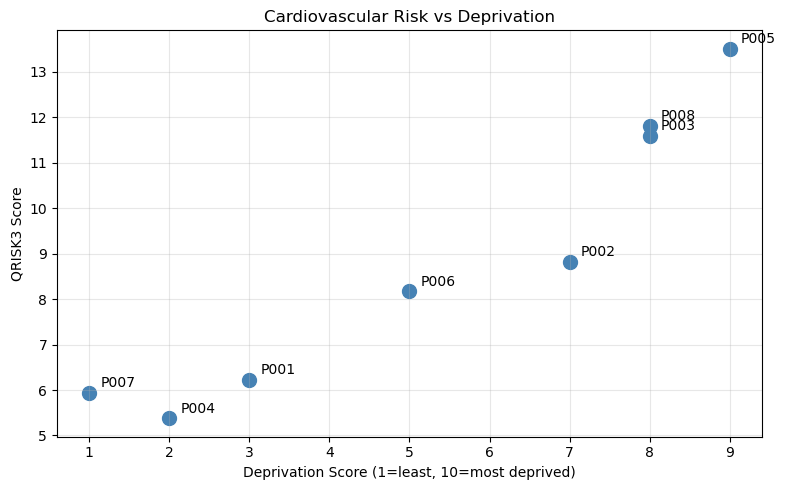

In [6]:
import matplotlib.pyplot as plt

# Scatter plot - deprivation vs qrisk score
plt.figure(figsize=(8, 5))
plt.scatter(df['deprivation'], df['qrisk_score'], color='steelblue', s=100)

# Label each point with patient ID
for i, row in df.iterrows():
    plt.annotate(row['patient_id'], (row['deprivation'], row['qrisk_score']), 
                textcoords="offset points", xytext=(8, 4))

plt.xlabel('Deprivation Score (1=least, 10=most deprived)')
plt.ylabel('QRISK3 Score')
plt.title('Cardiovascular Risk vs Deprivation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

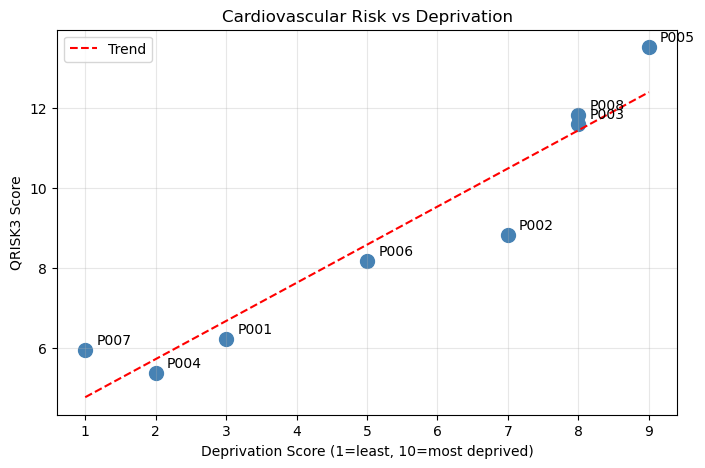

In [7]:
import numpy as np

z = np.polyfit(df['deprivation'], df['qrisk_score'], 1)
p = np.poly1d(z)

plt.figure(figsize=(8, 5))
plt.scatter(df['deprivation'], df['qrisk_score'], color='steelblue', s=100)

for i, row in df.iterrows():
    plt.annotate(row['patient_id'], (row['deprivation'], row['qrisk_score']),
                textcoords="offset points", xytext=(8, 4))

plt.plot(sorted(df['deprivation']), p(sorted(df['deprivation'])), 
         color='red', linestyle='--', label='Trend')

plt.xlabel('Deprivation Score (1=least, 10=most deprived)')
plt.ylabel('QRISK3 Score')
plt.title('Cardiovascular Risk vs Deprivation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()